# Christenson Ximenez: Model

# Set Up

In [1]:
import pandas as pd
import numpy as np

import matplotlib
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
from sklearn.decomposition import NMF, PCA

import sys
sys.path.append("../../local_lib/")
from hac2 import HAC

In [3]:
sns.set_theme(style='white')
px_template = 'plotly_white'

# Read in data

In [4]:
src_id = "christenson_ximenez"
n_chunks = 60
CHUNK = pd.read_csv(f"{src_id}-CHUNK-{n_chunks}.csv").set_index("chunk_num")
TFIDF = pd.read_csv(f"{src_id}-TFIDF-{n_chunks}.csv").set_index('chunk_num')

# TFIDF to TFIDF_SIM

In [5]:
 TFIDF_SIM = pd.DataFrame(cosine_similarity(TFIDF), index=TFIDF.index)

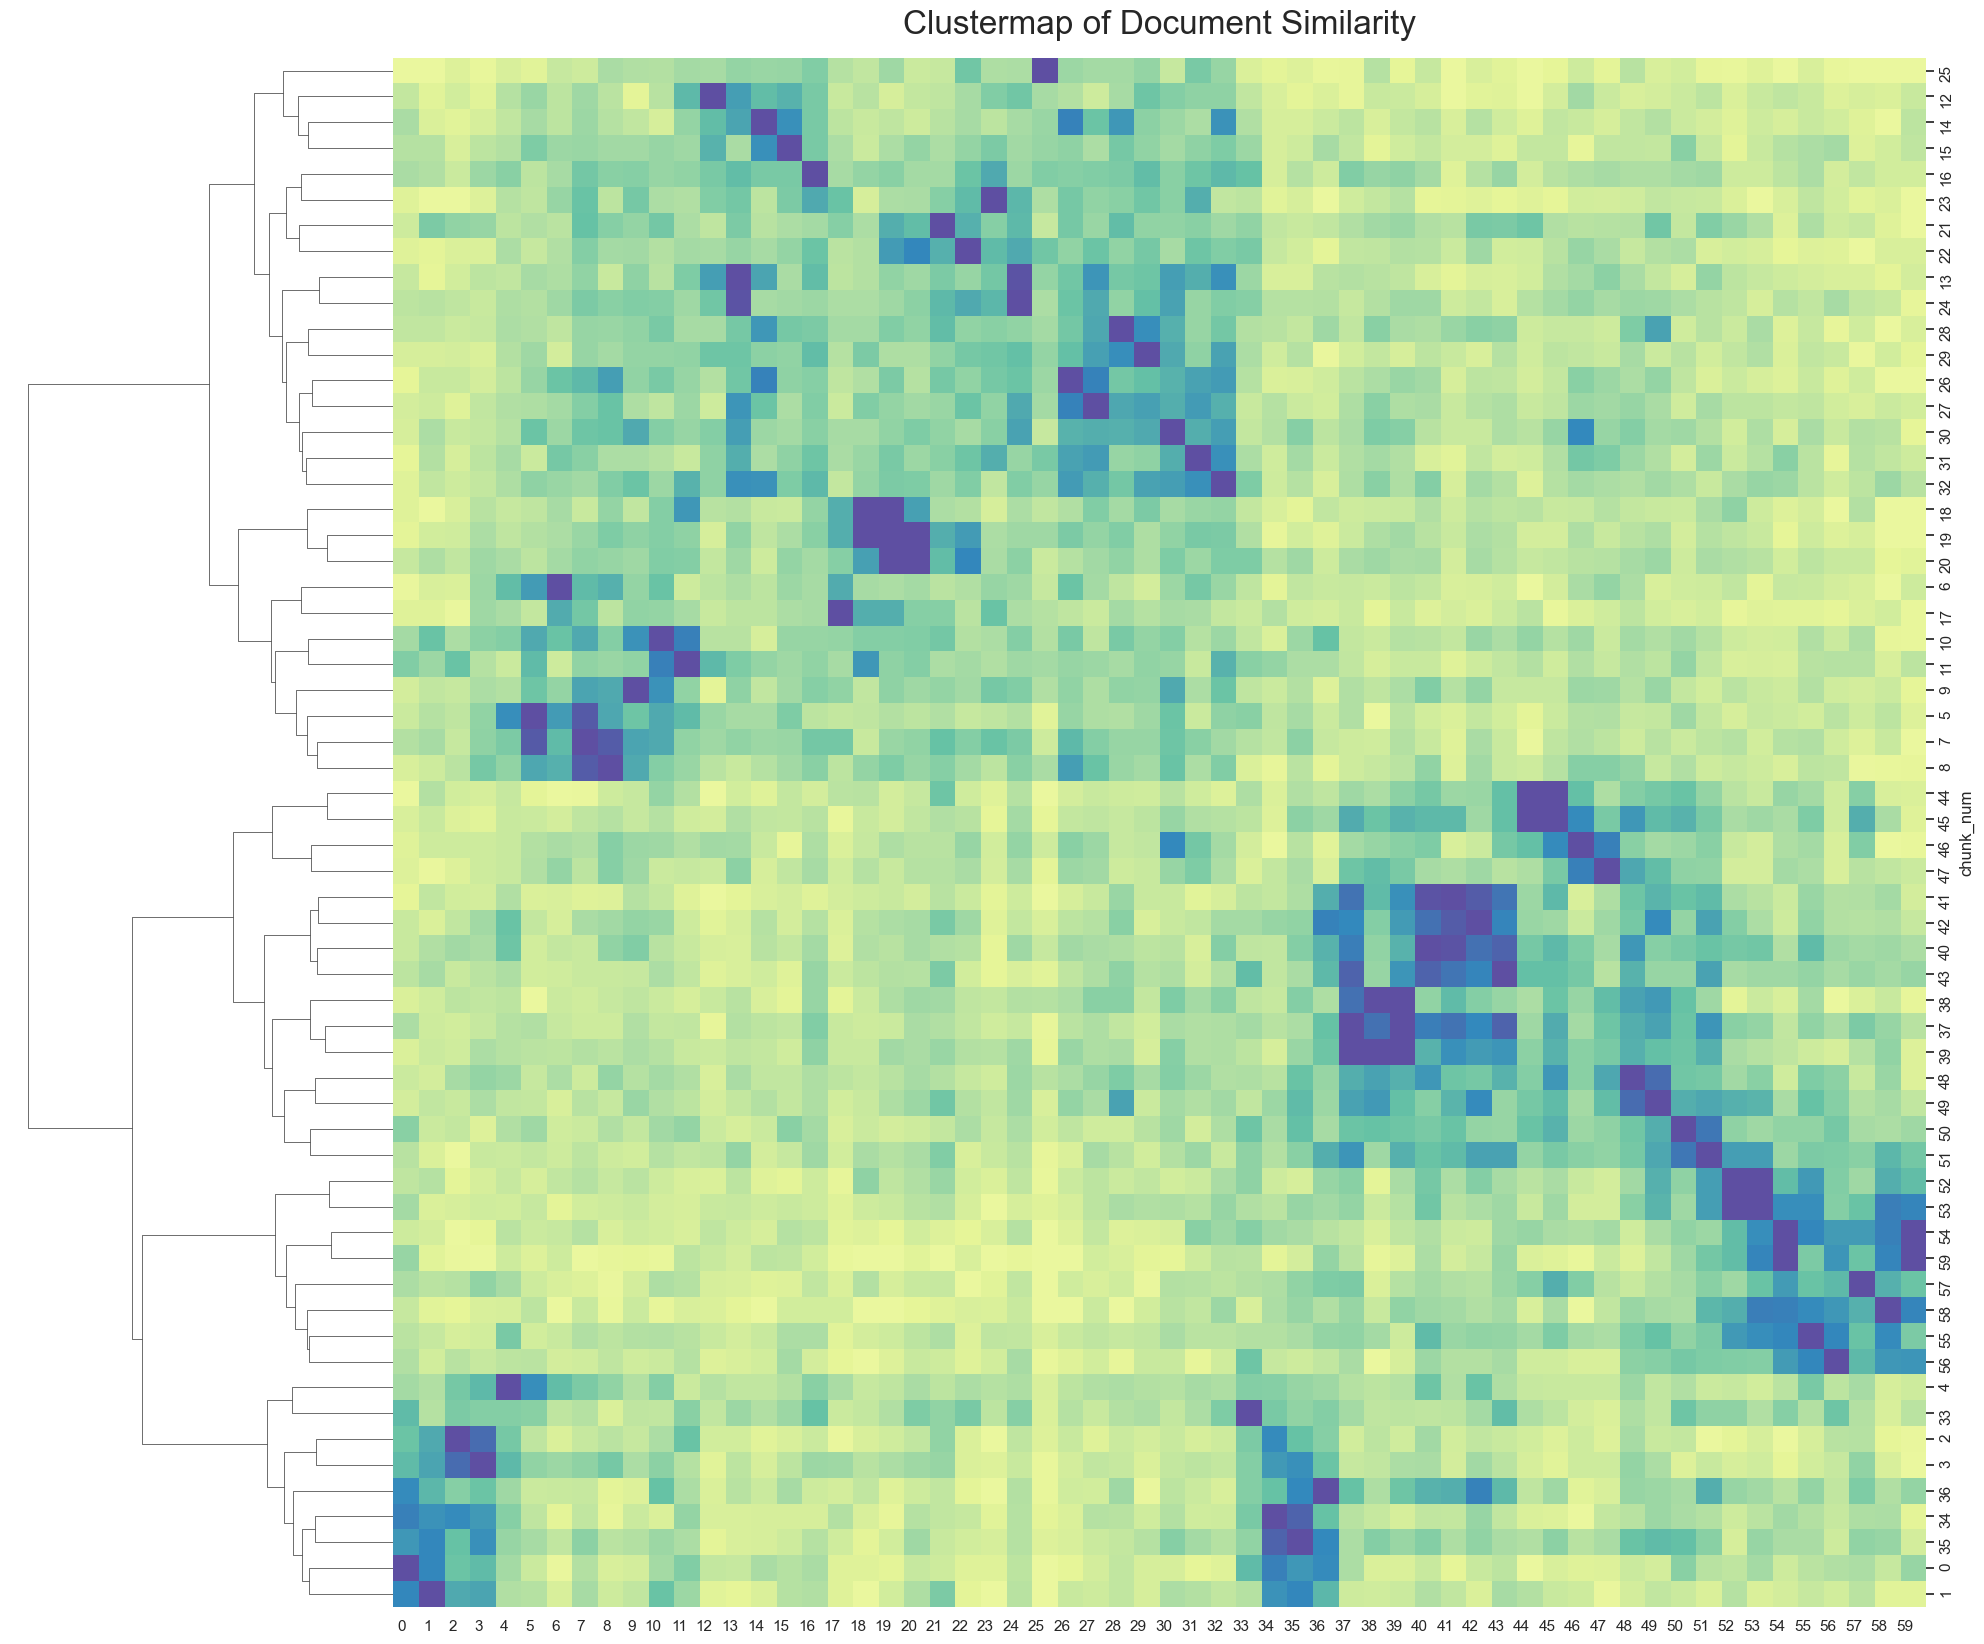

In [6]:
fig = sns.clustermap(TFIDF_SIM, 
               method='ward', metric='euclidean',
               cmap='Spectral', center=0, cbar_pos=None, 
               col_cluster=False, robust=True, 
               xticklabels=True, yticklabels=True, figsize=(20,20))
plt.setp(fig.ax_heatmap.get_xticklabels(), rotation=0, ha="right")
fig.ax_col_dendrogram.set_visible(False)
plt.title("Clustermap of Document Similarity", fontsize=24, y=1.01)
plt.savefig(f"{src_id}-tfidf-sims-clustermap.svg", bbox_inches='tight')
plt.savefig(f"{src_id}-tfidf-sims-clustermap.png", bbox_inches='tight')

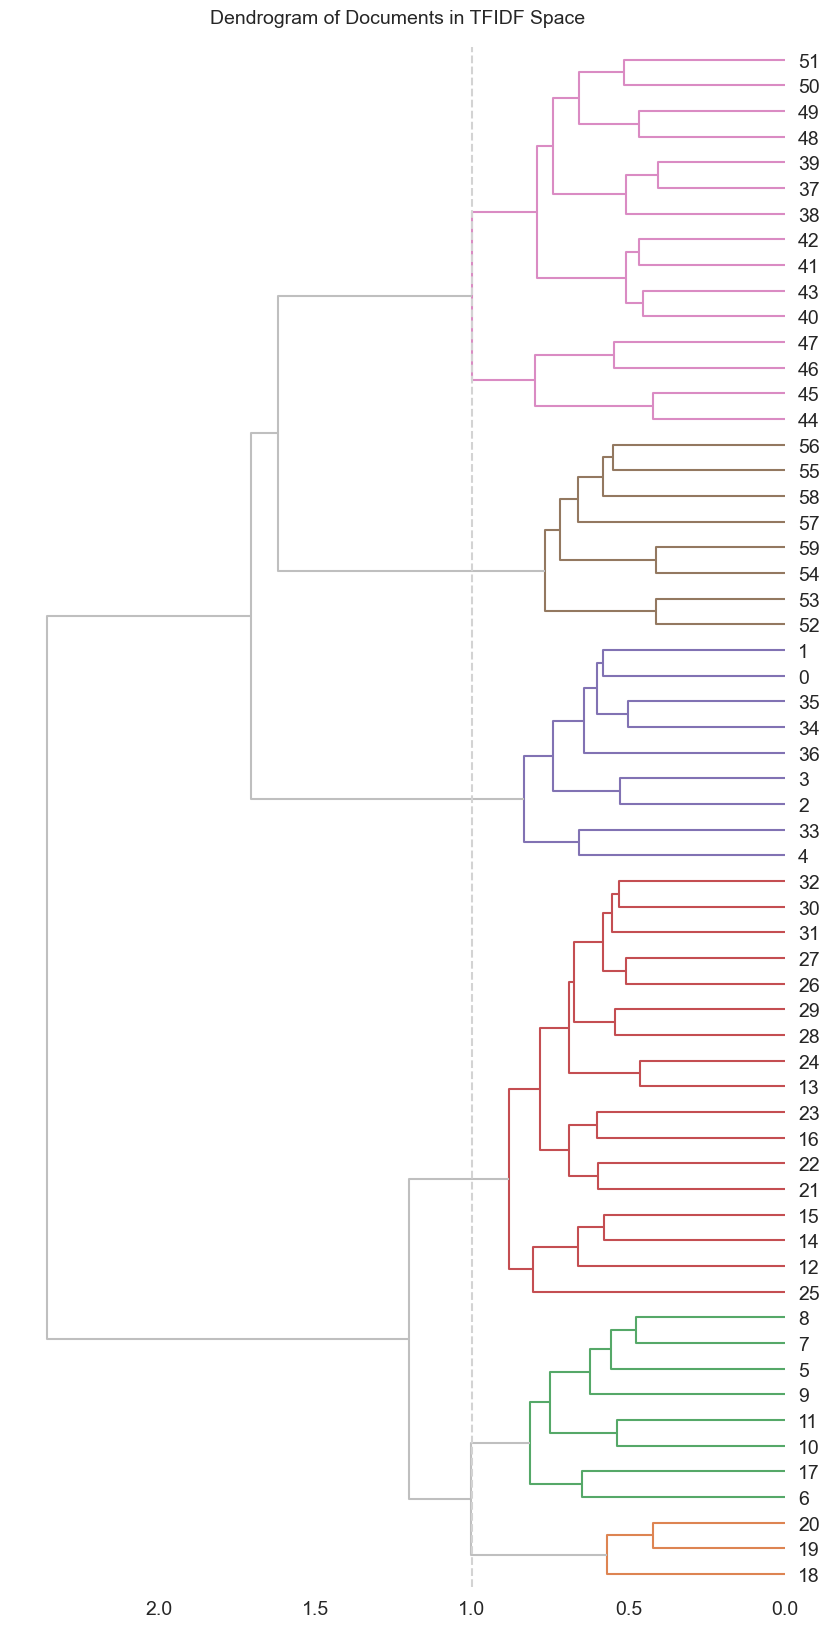

In [7]:
tfidf_hac = HAC(TFIDF_SIM)
tfidf_hac.color_thresh = 1
tfidf_hac.plot()
sns.despine(left=True, bottom=True)
plt.title("Dendrogram of Documents in TFIDF Space", fontsize=14, y=1.01)
plt.savefig(f"{src_id}-tfidf-sims-hac.svg", bbox_inches='tight')
plt.savefig(f"{src_id}-tfidf-sims-hac.png", bbox_inches='tight')
plt.show()

# TFIDF_SIMS to CLUSTER

In [8]:
tfidf_hac.get_cluster_labels()
CHUNK['hac_label'] = tfidf_hac.CLUSTER_LABELS
k = len(set(tfidf_hac.CLUSTER_LABELS))
k

6

In [9]:
CLUSTER = CHUNK.hac_label.value_counts().to_frame('n_chunks')
label_col = "hac_label"
CLUSTER['gloss'] = TFIDF.join(CHUNK[label_col]).groupby(label_col).mean().idxmax(1)
CLUSTER['top_terms'] = TFIDF.join(CHUNK[label_col]).groupby(label_col).mean().apply(lambda x: ', '.join(x.sort_values(ascending=False).head(7).index), axis=1)
CLUSTER.sort_index()

,n_chunks,gloss,top_terms
hac_label,,,
1,17,came,"came, xibalba, zamahel, quic, vholom, xqha, ahpu"
2,3,batz,"batz, catit, catz, chouen, choven, atit, che"
3,8,caquix,"caquix, qaholab, atit, vvcub, caib, cahoc, huiub"
4,9,cah,"cah, bit, qaholom, alom, bitol, tzacol, zaquil"
5,8,ahpop,"ahpop, ahau, quiche, tinamit, ahauab, chinamit..."
6,15,balam,"balam, tohil, quitze, amac, mahucutah, acab, iqui"


# TFIDF to PCA

In [10]:
n_comps = 5
pca_engine = PCA(n_components=n_comps)
PCAX = pd.DataFrame(pca_engine.fit_transform(TFIDF), index=TFIDF.index)
PCAX.index.name = 'doc_id'
LOADINGS = pd.DataFrame(pca_engine.components_.T * np.sqrt(pca_engine.explained_variance_), index = TFIDF.columns)
LOADINGS.index.name = 'term_str'

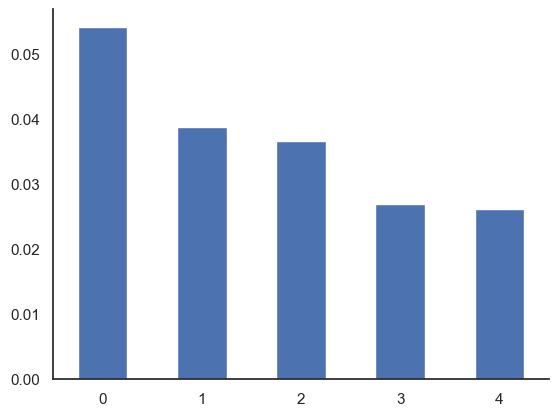

In [11]:
pd.Series(pca_engine.explained_variance_).plot.bar(rot=0)
sns.despine()
plt.show()

In [12]:
X0 = CHUNK.join(PCAX).join(CLUSTER, on=label_col)


In [13]:
def plot_pca(x, y):

    px.scatter(X0, x, y, 
        text=X0.index, 
        height=850, width=950, 
        color=X0.gloss,
        size = [1 for i in range(len(X0))],
        template=px_template,
        marginal_x='box', 
        # marginal_y='box'
    ).show()

    quantile = .99
    A = LOADINGS.loc[np.abs(LOADINGS[x]) >= np.abs(LOADINGS[x]).quantile(quantile), x]
    B = LOADINGS.loc[np.abs(LOADINGS[y]) >= np.abs(LOADINGS[y]).quantile(quantile), y]    
    C = pd.concat([A,B], axis=1).index

In [14]:
plot_pca(0,1)

In [15]:
plot_pca(1,2)

In [16]:
def comp_box(comp_id):
    px.box(X0,
           x=comp_id,
           y='gloss',
           color='gloss', 
           template=px_template,
           height=400, width=600, 
           title=f'PC {i}').show()
           
for i in range(n_comps):
    comp_box(i)

# TFIDF to NMF

In [17]:
k = 6

In [18]:
nmf_engine = NMF(n_components=k, max_iter=5000, init='nndsvda', solver='mu', beta_loss='kullback-leibler')
THETA = pd.DataFrame(nmf_engine.fit_transform(TFIDF), index=TFIDF.index)
# THETA_SIM = pd.DataFrame(cosine_similarity(THETA), index=THETA.index, columns=THETA.index)
PHI = pd.DataFrame(nmf_engine.components_, columns=TFIDF.columns)

In [19]:
n_topic_terms = 5
TOPIC = PHI.T.apply(lambda x: ', '.join(x.sort_values(ascending=False).head(n_topic_terms).index)).T.to_frame('top_terms')
TOPIC.index.name = 'topic_id'
CHUNK[f'top_topic_{k}'] = THETA.idxmax(1).values

In [ ]:
# with open("topics.md", "w") as outfile:
#     TOPIC.to_markdown(outfile)

In [21]:
TOPIC['gloss'] = PHI.idxmax(1)
TOPIC['label'] = TOPIC.apply(lambda x: f"{x.gloss} T{x.name}", axis=1)

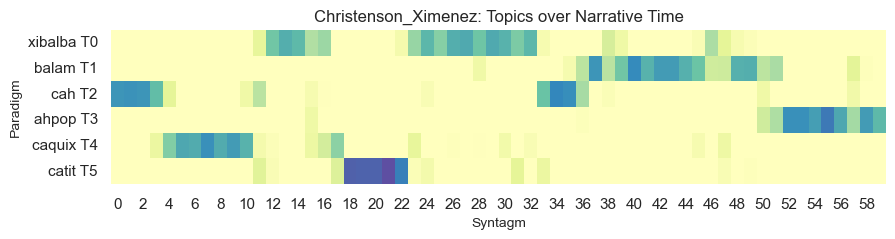

In [22]:
fig, ax = plt.subplots(figsize=(10,2))
sns.heatmap(
    THETA.T.set_index(TOPIC['label']), 
    cmap='Spectral', 
    center=0,
    cbar=None
)
plt.title(f"{src_id.title()}: Topics over Narrative Time")
ax.set_xlabel("Chunk Number", fontsize=10)
ax.set_ylabel("Topic", fontsize=10)
plt.savefig(f"{src_id}-topic-over-doc.svg", bbox_inches='tight')
plt.savefig(f"{src_id}-topic-over-doc.png", bbox_inches='tight')
plt.xlabel("Syntagm")
plt.ylabel("Paradigm")
plt.show()

# Save

In [23]:
CHUNK.to_csv(f"{src_id}-CHUNK2.csv", index=True)
CLUSTER.to_csv(f"{src_id}-CLUSTER.csv", index=True)
TOPIC.to_csv(f"{src_id}-TOPIC.csv", index=True)
THETA.to_csv(f"{src_id}-THETA.csv", index=True)
PHI.to_csv(f"{src_id}-PHI.csv", index=True)
LOADINGS.to_csv(f"{src_id}-PCA_LOADINGS.csv", index=True)
PCAX.to_csv(f"{src_id}-PCA_DCM.csv", index=True)